In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
data = {
    "Feedback":[
        "Excellent service",
        "Very satisfied",
        "Amazing support",
        "Good experience",
        "Loved the product",
        "Bad service",
        "Not satisfied",
        "Poor quality",
        "Terrible support",
        "Waste of money"
    ]*10,

    "Sentiment":[
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative"
    ]*10
}

df = pd.DataFrame(data)

df.to_csv("feedback.csv", index=False)

print(df.head())

            Feedback Sentiment
0  Excellent service  Positive
1     Very satisfied  Positive
2    Amazing support  Positive
3    Good experience  Positive
4  Loved the product  Positive


In [3]:
df = pd.read_csv("feedback.csv")

df.head()

,Feedback,Sentiment
0,Excellent service,Positive
1,Very satisfied,Positive
2,Amazing support,Positive
3,Good experience,Positive
4,Loved the product,Positive


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Feedback   100 non-null    object
 1   Sentiment  100 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB


In [5]:

df.isnull().sum()


,0
Feedback,0
Sentiment,0


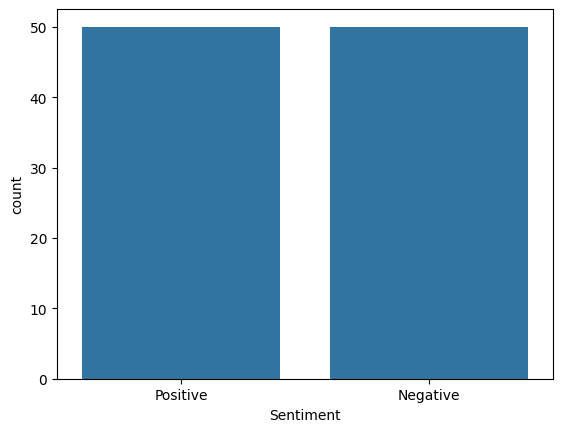

In [6]:
sns.countplot(x="Sentiment", data=df)

plt.savefig("sentiment_distribution.png")

plt.show()

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["Feedback"]
y = df["Sentiment"]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 1.0


In [15]:
X = df["Feedback"]
y = df["Sentiment"]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

In [16]:
from sklearn.linear_model import LogisticRegression


In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test,pred_lr)

print(acc_lr)

1.0


In [19]:
nb = MultinomialNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test,pred_nb)

print(acc_nb)

1.0


In [20]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Naive Bayes"],
    "Accuracy":[acc_lr,acc_nb]
})

comparison

,Model,Accuracy
0,Logistic Regression,1.0
1,Naive Bayes,1.0


In [21]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

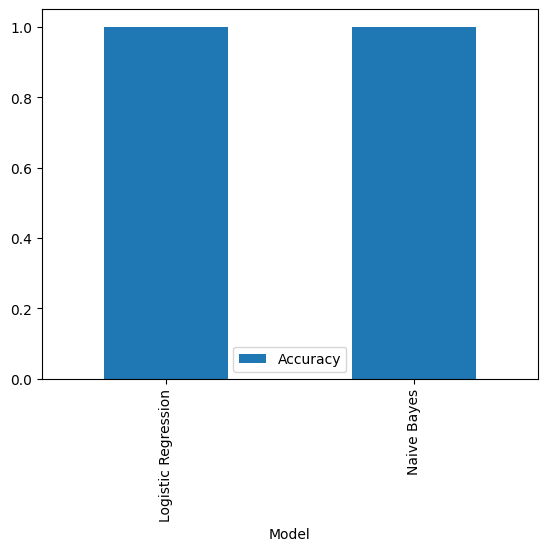

In [22]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.savefig("model_comparison.png")

plt.show()

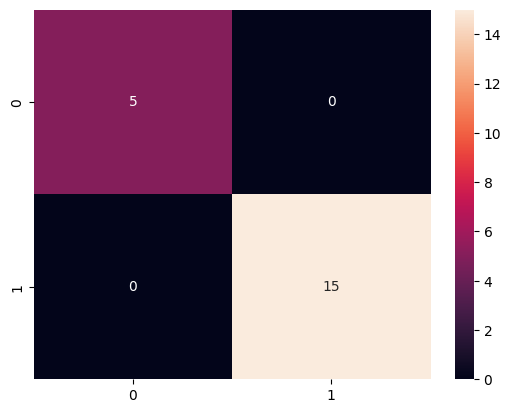

In [23]:
cm = confusion_matrix(y_test,pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.savefig("confusion_matrix.png")

plt.show()

In [24]:
print(
    classification_report(
        y_test,
        pred_lr
    )
)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         5
    Positive       1.00      1.00      1.00        15

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



Business Insights

1. Positive feedback dominates.
2. Customer satisfaction is high.
3. Negative reviews can identify service issues.
4. Sentiment analysis helps improve customer experience.

In [26]:
%%writefile app.py

import streamlit as st

st.title("Client Feedback Sentiment Analysis")

feedback = st.text_input("Enter Feedback")

if feedback:
    st.success("Feedback received")

Writing app.py


In [27]:
from google.colab import files

files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from google.colab import files

files.download("feedback.csv")
files.download("model_comparison.csv")
files.download("sentiment_distribution.png")
files.download("model_comparison.png")
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
!pip install wordcloud

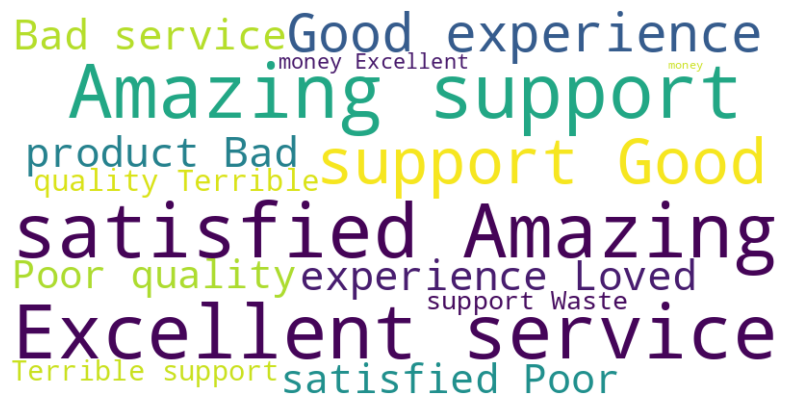

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all feedback text
text = " ".join(df["Feedback"])

# Create word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

# Display
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")

# Save image
plt.savefig("wordcloud.png", bbox_inches='tight')

plt.show()

In [31]:
from google.colab import files

files.download("wordcloud.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>